In [118]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,5)

from scipy.integrate import solve_ivp 

%matplotlib inline

## Allosteric activation

The reaction mechanism is as follows:
$$\begin{align*}
    A + E &\xrightleftharpoons[k_{-1}]{k_1} EA \\
    EA + S &\xrightleftharpoons[k_{-2}]{k_2} EAS \xrightarrow{k_3} P + EA 
\end{align*}
$$

Assuming that EA and EAS are in a quasi-steady-state, we find the following simplification of the governing ODEs to
$$\begin{align*}
    \dot{S(t)} &= -\frac{V_{max}S(t)A(t)}{K_1 + K_2A(t) + A(t)S(t)} \\
    \dot{P(t)} &= \frac{V_{max}S(t)A(t)}{K_1 + K_2A(t) + A(t)S(t)}
\end{align*},
$$
where $V_{max} = k_3 E_t$, $K_1 = \left[k_{-1}(k_{-2} + k_3)\right]/[k_1k_2]$, K_2 = [k_{-1} + k_3]/k_2.
Note that $E_t$ denotes the total enzyme concentration.

In [119]:
# define two sets of ODEs

# FULL SYSTEM
# p = [k_1, k_{-1}, k_2, k_{-2}, k_3, A, E_t]
# x = [S, EA, EAS,P]
def allo_activation_full(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[6] - x[1] - x[2] 
    dxdt[0] = -p[2]*x[1]*x[0] + p[3]*x[2]  #dSdt
    dxdt[1] =  p[0]*p[5]*E - p[1]*x[1] - p[2]*x[0]*x[1] + (p[3]+p[4])*x[2]  #dEAdt
    dxdt[2] = -p[3]*x[2] + p[2]*x[1]*x[0] - p[4]*x[2]  #dEASdt
    dxdt[3] =  p[4]*x[2]  #dPdt

    return dxdt


# REDUCED SYSTEM
# p = [Vmax, K_1, K_2, A]
# x = [S, P]
def allo_activation_reduced(t, x, p):
    dxdt = np.zeros(x.shape)

    dxdt[0] = -(p[0]*p[3]*x[0])/(p[1] + p[2]*p[3] + p[3]*x[0])  #dSdt
    dxdt[1] =  (p[0]*p[3]*x[0])/(p[1] + p[2]*p[3] + p[3]*x[0])  #dPdt

    return dxdt

Text(0.5, 0.98, 'Allosteric Activation of enzyme E by A')

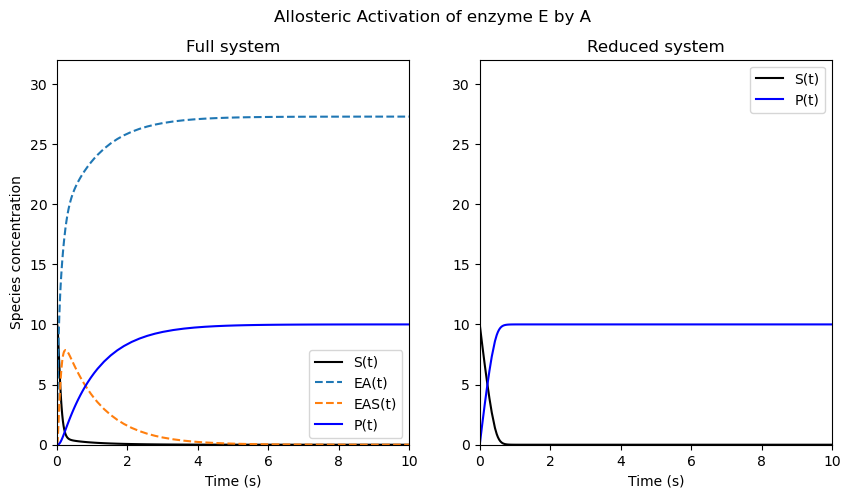

In [120]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
km2 = 1 #k_{-2}
k3 = 1
E_t = 30
A  = 2

Vmax = k3*E_t
K1 = (km1*(km2 + k3))/(k1*k2)
K2 = (km1 + k3)/k2

At = 10 # assume fixed activator concentration

p_full = np.array([k1, km1, k2, km2, k3, At, E_t])
p_reduced = np.array([Vmax, K1, K2, At])

# initial conditions
x0_full = np.array([10,0, 0, 0])
x0_reduced = np.array([10, 0])

# simulate
tspan = (0.0, 10.0)
x_sol_full = solve_ivp(allo_activation_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')
p_full_noA = np.array([k1, km1, k2, km2, k3, 0.1, E_t])
x_sol_full_noA = solve_ivp(allo_activation_full, tspan, x0_full, 
                            args=([p_full_noA]), method='BDF')
x_sol_reduced = solve_ivp(allo_activation_reduced, tspan, x0_reduced, 
                            args=([p_reduced]), method='BDF')

fig, ax = plt.subplots(1,2)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], color='blue')
ax[0].legend(['S(t)','EA(t)', 'EAS(t)', 'P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Full system')

ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[0], color='black')
ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[1], color='blue')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_xlabel('Time (s)')
ax[1].legend(['S(t)','P(t)'])
ax[1].set_title('Reduced system')
fig.suptitle('Allosteric Activation of enzyme E by A')

Text(0.5, 1.0, 'Activator $A = 0.1$')

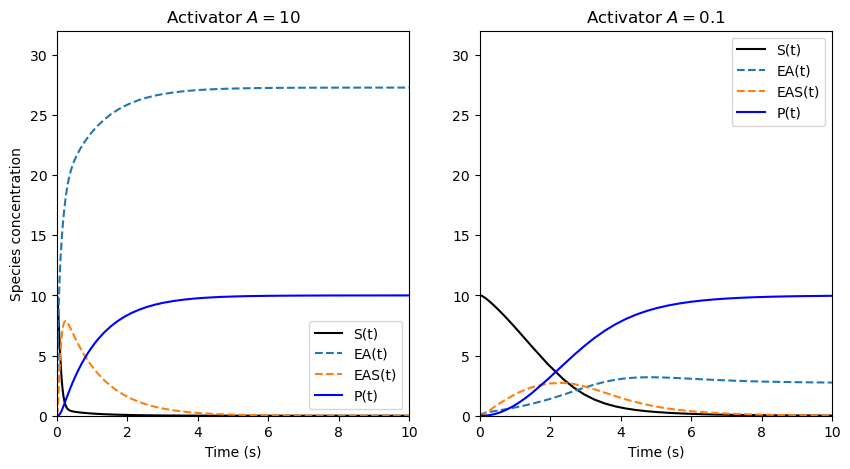

In [121]:
fig, ax = plt.subplots(1,2)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], color='blue')
ax[0].legend(['S(t)','EA(t)', 'EAS(t)', 'P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Activator $A=10$')

ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[0], color='black')
ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[1], '--')
ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[2], '--')
ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[3], color='blue')
ax[1].legend(['S(t)','EA(t)', 'EAS(t)', 'P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_title('Activator $A = 0.1$')

## Allosteric Inhibition

The reaction mechanism is as follows:
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
\end{align*}
$$

In [122]:
# define two sets of ODEs

# FULL SYSTEM
# p = [k_1, k_{-1}, k_2, k_3, k_{m3}, I, E_t]
# x = [S, ES, EI, ESI, P]
def allo_inhibition_full(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[6] - x[1] - x[2] - x[3]
    dxdt[0] = -p[0]*x[0]*E + p[1]*x[1]  #dSdt
    dxdt[1] =  p[0]*x[0]*E - (p[1]+p[2])*x[1] + (p[4]-p[3])*x[3]  #dESdt
    dxdt[2] =  p[3]*p[5]*E - p[4]*x[3] - p[0]*x[0]*x[2] + p[1]*x[3]  #dEIdt
    dxdt[3] =  p[3]*p[5]*x[1] - (p[4]+p[1])*x[3] + p[0]*x[0]*x[2]  #dESIdt
    dxdt[4] =  p[2]*x[1]  #dPdt

    return dxdt

# REDUCED SYSTEM
# TBD

Text(0.5, 1.0, 'No Inhibitor ($I=0$)')

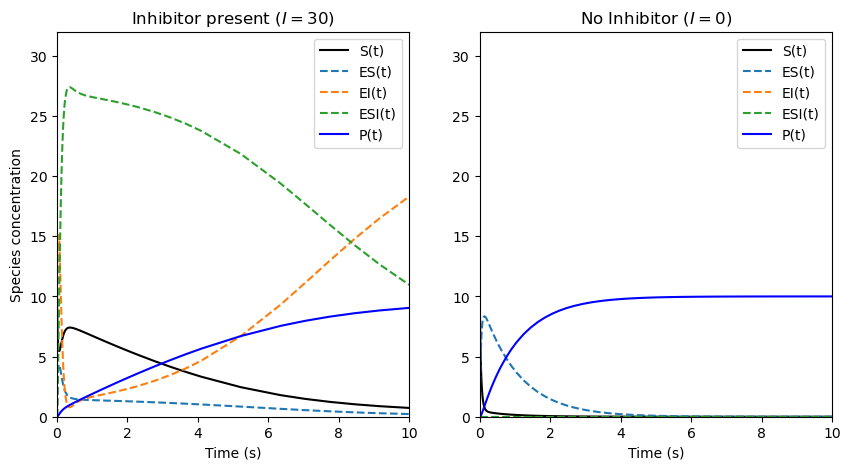

In [123]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
k3 = 1
km3 = 1
E_t = 30

It = 30 # assume fixed inhibitor concentration

p_full = np.array([k1, km1, k2, k3, km3, It, E_t])
# p_reduced = np.array([Vmax, K1, K2, At])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0])
# x0_reduced = np.array([10, 0])

# simulate
tspan = (0.0, 10.0)
p_full = np.array([k1, km1, k2, k3, km3, It, E_t])
x_sol_full = solve_ivp(allo_inhibition_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noI = np.array([k1, km1, k2, k3, km3, 0, E_t])
x_sol_full_noI = solve_ivp(allo_inhibition_full, tspan, x0_full, 
                            args=([p_full_noI]), method='BDF')
# x_sol_reduced = solve_ivp(allo_activation_reduced, tspan, x0_reduced, 
                            # args=([p_reduced]), method='BDF')


fig, ax = plt.subplots(1,2)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[4], color='blue')
ax[0].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Inhibitor present ($I=30$)')

ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], color='black')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[1], '--')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[2], '--')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[3], '--')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[4], color='blue')
ax[1].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_title('No Inhibitor ($I=0$)')

## Inhibition of Allosteric Activation

The proposed reaction mechanism is as follows:
$$\begin{align*}
    A + E &\xrightleftharpoons[k_{-1}]{k_1} EA \\
    EA + S &\xrightleftharpoons[k_{-2}]{k_2} EAS \xrightarrow{k_3} P + EA \\
    I + E &\xrightleftharpoons[k_{-4}]{k_4} EI \\
    A + EI &\xrightleftharpoons[k_{-1}]{k_1} EAI \\
    I + EA &\xrightleftharpoons[k_{-4}]{k_4} EAI \\
    I + EAS &\xrightleftharpoons[k_{-4}]{k_4} EASI \\
    S + EAI &\xrightleftharpoons[k_{-2}]{k_2} EASI \\
\end{align*}
$$


In [124]:
# define ODE
# FULL SYSTEM
# p =[k_1, k_{-1}, k_2, k_{-2}, k_3, k_4, k_{-4}, I, A, E_t]
# x = [S, EA, EI, EAS, EAI, EASI, P]

def inhib_activ_full(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = -p[2]*x[1]*x[0] + p[3]*x[3]  #dSdt
    dxdt[1] = (p[0]*p[8]*E - (p[1] + p[5]*p[7] + p[2]*x[0])*x[1] + 
        (p[3]+p[4])*x[3] + p[6]*x[4])  #dEAdt
    dxdt[2] = p[5]*p[8]*E - (p[6] + p[0]*p[8])*x[2] + p[1]*x[4] #dEIdt
    dxdt[3] = p[2]*x[1]*x[0] - (p[3] + p[4] + p[5]*p[7])*x[3] + p[6]*x[5]  #dEASdt
    dxdt[4] = (p[5]*p[7]*x[1] - (p[6] + p[2]*x[0] + p[1])*x[4] + p[3]*x[5] 
        + p[0]*p[8]*x[2])  #dEAIdt
    dxdt[5] = p[5]*p[7]*x[3] - (p[6] + p[2])*x[5] + p[2]*x[0]*x[4]  #dEASIdt
    dxdt[6] = p[4]*x[3]  #dPdt

    return dxdt

Text(0.5, 1.0, 'Reduced Inhibitor ($I = 0.3$)\n Full Activation ($A=10$)')

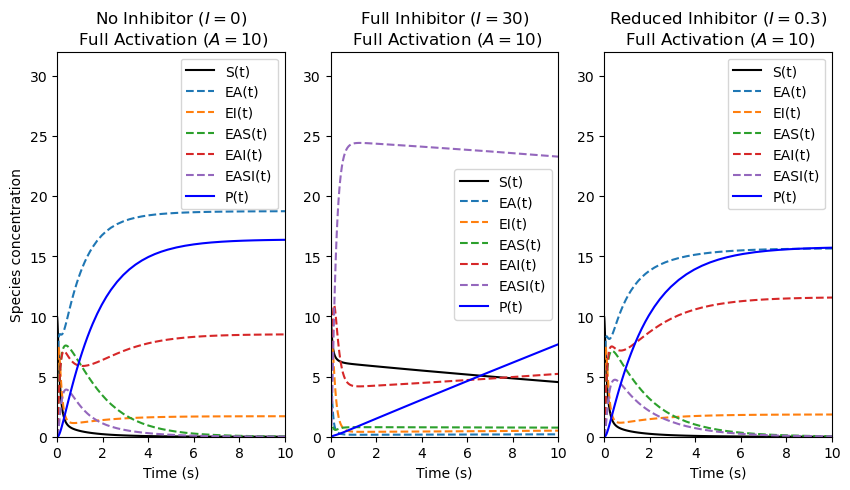

In [127]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
km2 = 1
k3 = 1
k4 = 1
km4 = 1

E_t = 30

It = 30 # assume fixed activator/inhibitor concentration
At = 10

p_full = np.array([k1, km1, k2, km2, k3, k4, km4, It, At, E_t])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0, 0, 0])

# simulate
tspan = (0.0, 10.0)
x_sol_full = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, At, E_t])
x_sol_full_noI = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_noI]), method='BDF')

p_full_redA = np.array([k1, km1, k2, km2, k3, k4, km4, It, 0.1, E_t])
x_sol_full_redA = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_redA]), method='BDF')

p_full_redAnoI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, 0.1, E_t])
x_sol_full_redAnoI = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_redAnoI]), method='BDF')

p_full_redI = np.array([k1, km1, k2, km2, k3, k4, km4, 0.3, At, E_t])
x_sol_full_redI = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_redI]), method='BDF')


fig, ax = plt.subplots(1,3)
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], color='black')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[1], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[2], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[3], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[4], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[5], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[6], color='blue')
ax[0].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('No Inhibitor ($I=0$)\n Full Activation ($A=10$)')

ax[1].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[1].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[1].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_title('Full Inhibitor ($I = 30$)\n Full Activation ($A=10$)')

ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[0], color='black')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[1], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[2], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[3], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[4], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[5], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[6], color='blue')
ax[2].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, 10])
ax[2].set_title('Reduced Inhibitor ($I = 0.3$)\n Full Activation ($A=10$)')


## Inhibition of Allosteric Inhibition

Mechanism 1 is as follows:
Here the second inhibitor $R$ can replace the initial inhibitor $I$.
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
    E + R &\xrightleftharpoons[k_{-4}]{k_4} ER \\
    S + ER &\xrightleftharpoons[k_{-1}]{k_1} ERS \xrightarrow{k_2} P + ER \\
    R + EI &\xrightleftharpoons[k_{-4}]{k_4} ER + I\\
    R + ESI &\xrightleftharpoons[k_{-4}]{k_4} ERS + I\\
\end{align*}
$$

Mechanism 2 is as follows:
Here the second inhibitor $R$ only competes with the initial inhibitor $I$.
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
    E + R &\xrightleftharpoons[k_{-4}]{k_4} ER \\
    S + ER &\xrightleftharpoons[k_{-1}]{k_1} ERS \xrightarrow{k_2} P + ER \\
\end{align*}
$$

In [151]:
# define ODEs

# FULL SYSTEM 1
# p = [k_1, k_{-1}, k_2, k_3, k_{-3}, k_4, k_{-4}, I, R, E_t]
# x = [S, ES, EI, ER, ESI, ERS, P]
def inhib_inhib_m1_full(t,x,p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = -p[0]*x[0]*(E+x[2]+x[3]) + p[1]*(x[1]+x[4]+x[5])  #dSdt
    dxdt[1] = p[0]*x[0]*E - p[1]*x[1] - p[3]*p[7]*x[1] + p[4]*x[4]  #dESdt
    dxdt[2] = (p[3]*p[7]*E - p[3]*x[2] - p[0]*x[0]*x[2] + p[1]*x[4] - 
        p[5]*p[8]*x[2] + p[6]*x[3]*p[7])  #dEIdt
    dxdt[3] = (p[5]*E*p[8] - p[6]*x[3] - p[0]*x[0]*x[3] + p[1]*x[4] + 
        p[5]*p[8]*x[2] - p[6]*x[3]*p[7])  #dERdt
    dxdt[4] = (p[5]*p[7]*x[1] - p[4]*x[4] + p[0]*x[0]*x[2] - p[1]*x[4] - 
        p[5]*p[8]*x[4] + p[6]*x[5]*p[7])  #dESIdt
    dxdt[5] = (p[0]*x[0]*x[3] - p[1]*x[5] - p[2]*x[5] + p[5]*p[8]*x[4] -
        p[6]*x[5]*p[7])  #dERSdt
    dxdt[6] = p[2]*x[1] + p[2]*x[5]  #dPdt

    return dxdt

# FULL SYSTEM 2
# p = [k_1, k_{-1}, k_2, k_3, k_{-3}, I, R, E_t]
# x = [S, ES, EI, ER, ESI, ERS, P]
def inhib_inhib_m2_full(t,x,p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = -(x[2]+E+x[3])*p[0]*x[0] + p[1]*(x[1]+x[4]+x[5])  #dSdt
    dxdt[1] = p[0]*x[0]*E - p[1]*x[1] - p[3]*p[7]*x[1] + p[4]*x[4]  #dESdt
    dxdt[2] = p[3]*p[7]*E - p[4]*x[2] - p[0]*x[0]*x[2] + p[1]*x[4]  #dEIdt
    dxdt[3] = p[5]*E*p[8] - p[6]*x[3] - p[0]*x[0]*x[3] + (p[1]+p[2])*x[5]  #dERdt
    dxdt[4] = p[3]*p[7]*x[1] - p[6]*x[3] - p[0]*x[0]*x[2] - p[1]*x[4]  #dESIdt
    dxdt[5] = p[0]*x[0]*x[3] - (p[1]+p[2])*x[5]  #dERSdt
    dxdt[6] = p[2]*(x[1]+x[5])

    return dxdt

Text(0.5, 1.05, 'Inhibition of Inhibition: Full Mechanism 1')

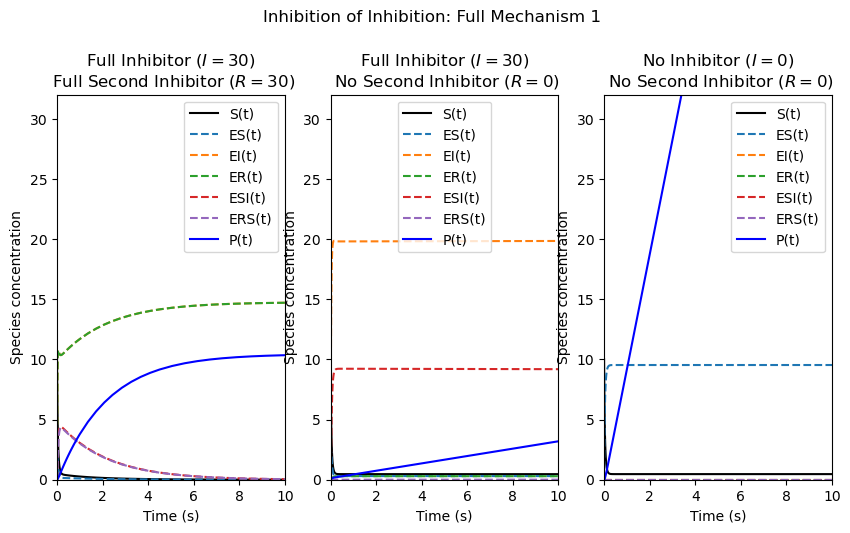

In [152]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
k3 = 1
km3 = 1
k4 = 1
km4 = 1

E_t = 30

It = 30 # assume fixed activator/inhibitor concentration
Rt = 30

p_full = np.array([k1, km1, k2, k3, km3, k4, km4, It, Rt, E_t])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0, 0, 0])

# simulate
tspan = (0.0, 10.0)
x_sol_full = solve_ivp(inhib_inhib_m1_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noR = np.array([k1, km1, k2, k3, km3, k4, km4, It, 0, E_t])
x_sol_full_noR = solve_ivp(inhib_inhib_m1_full, tspan, x0_full, 
                            args=([p_full_noR]), method='BDF')

p_full_noRnoI = np.array([k1, km1, k2, k3, km3, k4, km4, 0, 0, E_t])
x_sol_full_noRnoI = solve_ivp(inhib_inhib_m1_full, tspan, x0_full, 
                            args=([p_full_noRnoI]), method='BDF')


fig, ax = plt.subplots(1,3)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[0].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Full Inhibitor ($I = 30$)\n Full Second Inhibitor ($R=30$)')

ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[0], color='black')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[1], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[2], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[3], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[4], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[5], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[6], color='blue')
ax[1].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_ylabel('Species concentration')
ax[1].set_title('Full Inhibitor ($I = 30$)\n No Second Inhibitor ($R=0$)')

ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[0], color='black')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[1], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[2], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[3], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[4], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[5], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[6], color='blue')
ax[2].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, 10])
ax[2].set_ylabel('Species concentration')
ax[2].set_title('No Inhibitor ($I = 0$)\n No Second Inhibitor ($R=0$)')
fig.suptitle('Inhibition of Inhibition: Full Mechanism 1', y=1.05)


Text(0.5, 1.05, 'Inhibition of Inhibition: Full Mechanism 2')

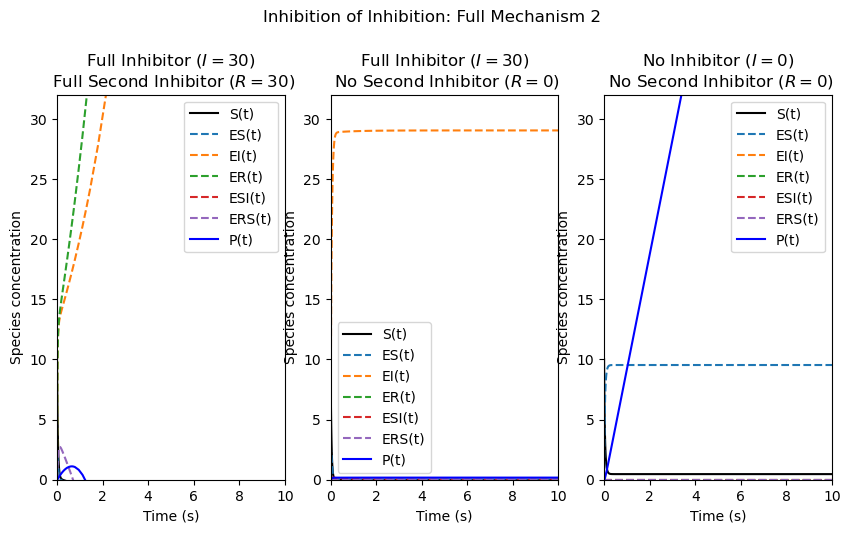

In [153]:
p_full = np.array([k1, km1, k2, k3, km3, k4, km4, It, Rt, E_t])
x_sol_full = solve_ivp(inhib_inhib_m2_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noR = np.array([k1, km1, k2, k3, km3, k4, km4, It, 0, E_t])
x_sol_full_noR = solve_ivp(inhib_inhib_m2_full, tspan, x0_full, 
                            args=([p_full_noR]), method='BDF')

p_full_noRnoI = np.array([k1, km1, k2, k3, km3, k4, km4, 0, 0, E_t])
x_sol_full_noRnoI = solve_ivp(inhib_inhib_m2_full, tspan, x0_full, 
                            args=([p_full_noRnoI]), method='BDF')


fig, ax = plt.subplots(1,3)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[0].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Full Inhibitor ($I = 30$)\n Full Second Inhibitor ($R=30$)')

ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[0], color='black')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[1], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[2], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[3], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[4], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[5], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[6], color='blue')
ax[1].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_ylabel('Species concentration')
ax[1].set_title('Full Inhibitor ($I = 30$)\n No Second Inhibitor ($R=0$)')

ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[0], color='black')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[1], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[2], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[3], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[4], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[5], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[6], color='blue')
ax[2].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, 10])
ax[2].set_ylabel('Species concentration')
ax[2].set_title('No Inhibitor ($I = 0$)\n No Second Inhibitor ($R=0$)')
fig.suptitle('Inhibition of Inhibition: Full Mechanism 2', y=1.05)